(sec:molecular_representations)=

# Molecular Representations

This section introduces practical considerations for applying deep learning in chemistry. Although deep learning has many chemical applications, we focus on tasks that learn from molecular data, such as predicting properties of distinct molecular species. A central question is how to represent molecules in a form that machine learning models can use. The choice of representation can strongly affect model performance, sometimes as much as the model architecture itself.

## Overview

Formally, for a set of distinct molecules, we seek a vector representation $\vec{x}_i \in \mathbb{R}^d$ for each molecule $i$. This representation should identify the molecule and capture enough chemical information to predict a property $y_i$ from $\vec{x}_i$ in a supervised learning setting. The overview below is not exhaustive; it illustrates common types of molecular representations and the ideas behind them.

:::{note} One-hot encoding

A simple way to create a unique vector representation for arbitrary data is **one-hot encoding**. For $N$ data points, the $i$-th data point is represented by a vector of length $N$ with a single $1$ at position $i$ and zeros everywhere else. This representation is useful in some tasks, but it contains no domain-specific information.

:::

### String-based representations

String-based representations are not vector representations in the usual sense, but they are widely used to identify, draw, and convert molecules. The most common example is the **S**implified **M**olecular **I**nput **L**ine **E**ntry **S**ystem ([SMILES](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system)). In SMILES, atoms are represented by characters, hydrogen atoms are usually omitted, and molecular connectivity is implied by the order of the characters. For example, ethanol is represented by the SMILES string `CCO`. Rings are written by breaking them into acyclic strings at arbitrary atoms and marking the corresponding ring closures with numbers (e.g. `CC(=O)NCCC1=CNc2c1cc(OC)cc2`, melatonin). 

A powerful tool for working with SMILES strings is [`rdkit`](https://www.rdkit.org), which provides functions for parsing, drawing, and converting between molecular representations.

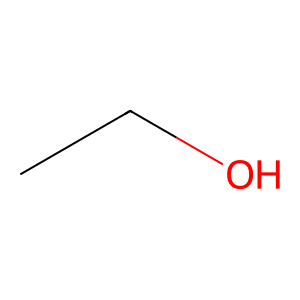

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# Define a SMILES string and create a molecule object
smiles = 'CCO'
mol = Chem.MolFromSmiles(smiles)

# Draw the molecule
Draw.MolToImage(mol)

SMILES strings have several limitations, so alternative string-based representations have also been developed, including [SMARTS](https://en.wikipedia.org/wiki/SMILES_arbitrary_target_specification) and [InChI](https://en.wikipedia.org/wiki/International_Chemical_Identifier).

### Descriptor-based representations

Because machine learning models are typically trained on numerical inputs, string-based molecular identifiers cannot usually be used directly in deep-learning applications. A common alternative is to derive **hand-crafted numerical descriptors** $x_j$ from a molecular representation such as a SMILES string, concatenate them, and use the resulting vector $\vec{x} = (x_1, x_2, \ldots, x_d)^\top$ as model input.

These descriptors can encode chemically or physically motivated molecular features, such as molecular weight, the number of rotatable bonds, the topological polar surface area, or the dipole moment. They are often highly interpretable and can introduce strong chemical domain knowledge through the choice of descriptors. 

In `rdkit`, many such descriptors are available through the `Descriptors` module.

In [5]:
from rdkit.Chem import Descriptors

# Get a list of all descriptor names and their corresponding functions
desc_list = Descriptors._descList

# Print the value of each descriptor for the molecule
for desc_name, desc_function in desc_list[:10]:
    value = desc_function(mol)
    print(f"{desc_name}: {value}")

MaxAbsEStateIndex: 7.569444444444445
MaxEStateIndex: 7.569444444444445
MinAbsEStateIndex: 0.25
MinEStateIndex: 0.25
qed: 0.4068079656553945
SPS: 6.0
MolWt: 46.069
HeavyAtomMolWt: 40.021
ExactMolWt: 46.041864812
NumValenceElectrons: 20


### Fingerprint representations

Hand-crafted descriptors are informative, but they may miss subtle structural differences that are important for learning relationships between molecular properties and molecular structure. A more structure-driven approach is to use a molecular fingerprint: a fixed-length binary vector that encodes the presence or absence of substructures in a molecule.

A widely used example is the **E**xtended **C**ircular **F**inger**p**rint (ECFP), which is based on the Morgan fingerprint algorithm. This algorithm first assigns each atom an identifier based on local atomic properties, then iteratively updates these identifiers by incorporating information from neighbouring atoms at increasing radii. After duplicate substructures have been removed, the resulting identifiers are hashed into a fixed-length bit vector, where each active bit indicates the presence of a particular local molecular environment. 

Other fingerprint types include MACCS keys; `rdkit` provides dedicated generators for several fingerprint representations.

In [6]:
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

# Create a fingerprint generator
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=1024)

# Generate a fingerprint (bit vector) and print as numpy array
fp = mfpgen.GetFingerprint(mol)
print(np.array(fp))

[0 0 0 ... 0 0 0]


### Geometric (3D) representations

Many molecular properties depend on the 3D geometry of a molecule, meaning the precise arrangement of atoms in space. A central challenge for 3D-aware representations is *invariance* to the orientation of the molecule: the representation should not change when the atomic coordinates are rotated or translated. One common way to achieve this is to encode molecular geometry through interatomic distances, for example with the **Coulomb matrix** $\bm{M}$:

$$
M_{ij} = \begin{cases}
0.5 \, Z_i^{2.4} & \text{if } i = j \\
\frac{Z_i Z_j}{R_{ij}} & \text{if } i \neq j
\end{cases}
$$

Here, $Z_i$ is the atomic number of atom $i$, and $R_{ij}$ is the distance between atoms $i$ and $j$. Since the Coulomb matrix still depends on the ordering of atoms, and since matrices are not always convenient as direct neural-network inputs, it is often diagonalised and represented by its sorted eigenvalues. Molecules with different numbers of atoms can be handled by padding the resulting feature vectors with zeros.

### Learned representations

In recent years, evidence from chemistry and other fields has suggested that much of the success of deep learning comes from the ability of neural networks to learn useful internal representations of the input data. Early layers can encode the input in a form that is more informative for later layers, such as shapes or patterns in images, while later layers use this information for the final regression or classification task.

In practice, this often means training a separate model to produce a compressed numerical representation, called an **embedding**, that is useful for a particular learning objective. The training data is then passed through this embedding model, and the resulting embeddings are used as input to the downstream model. Learned representations are usually less interpretable than hand-crafted descriptors, but they often achieve the highest predictive performance.
